In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset directly from Keras
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize images to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert RGB images to grayscale
def rgb_to_grayscale(im3ages):
    return tf.image.rgb_to_grayscale(images)

x_train_grayscale = rgb_to_grayscale(x_train)
x_test_grayscale = rgb_to_grayscale(x_test)

print(f"شکل دیتاست رنگی: {x_train.shape}")
print(f"شکل دیتاست سیاه و سفید: {x_train_grayscale.shape}")

شکل دیتاست رنگی: (50000, 32, 32, 3)
شکل دیتاست سیاه و سفید: (50000, 32, 32, 1)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def create_colorization_model():
    # Encoder
    encoder_input = keras.Input(shape=(32, 32, 1))
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    # Output layer
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = keras.Model(encoder_input, decoder_output)
    return model

model = create_colorization_model()
model.summary()

Model: "functional_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_61 (InputLayer)     │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,627 (2.54 MB)

 Trainable params: 666,627 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
# The number of epochs is the number of times the model will go through the entire dataset
history = model.fit(
    x_train_grayscale,
    x_train,
    epochs=50,  # You can start with 20 and adjust later
    batch_size=64,
    validation_split=0.1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 0.0042 - val_loss: 0.0064
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0037 - val_loss: 0.0062
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0036 - val_loss: 0.0066
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0037 - val_loss: 0.0063
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0036 - val_loss: 0.0062
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0035 - val_loss: 0.0062
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0035 - val_loss: 0.0064
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0035 - val_loss: 0.0065
Epoch 9/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0035 - val_loss: 0.0064
Epoch 10/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0035 - val_loss: 0.0063
Epoch 11/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0034 - val_loss: 0.0067
Epoch 12/50
704/704 ━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step


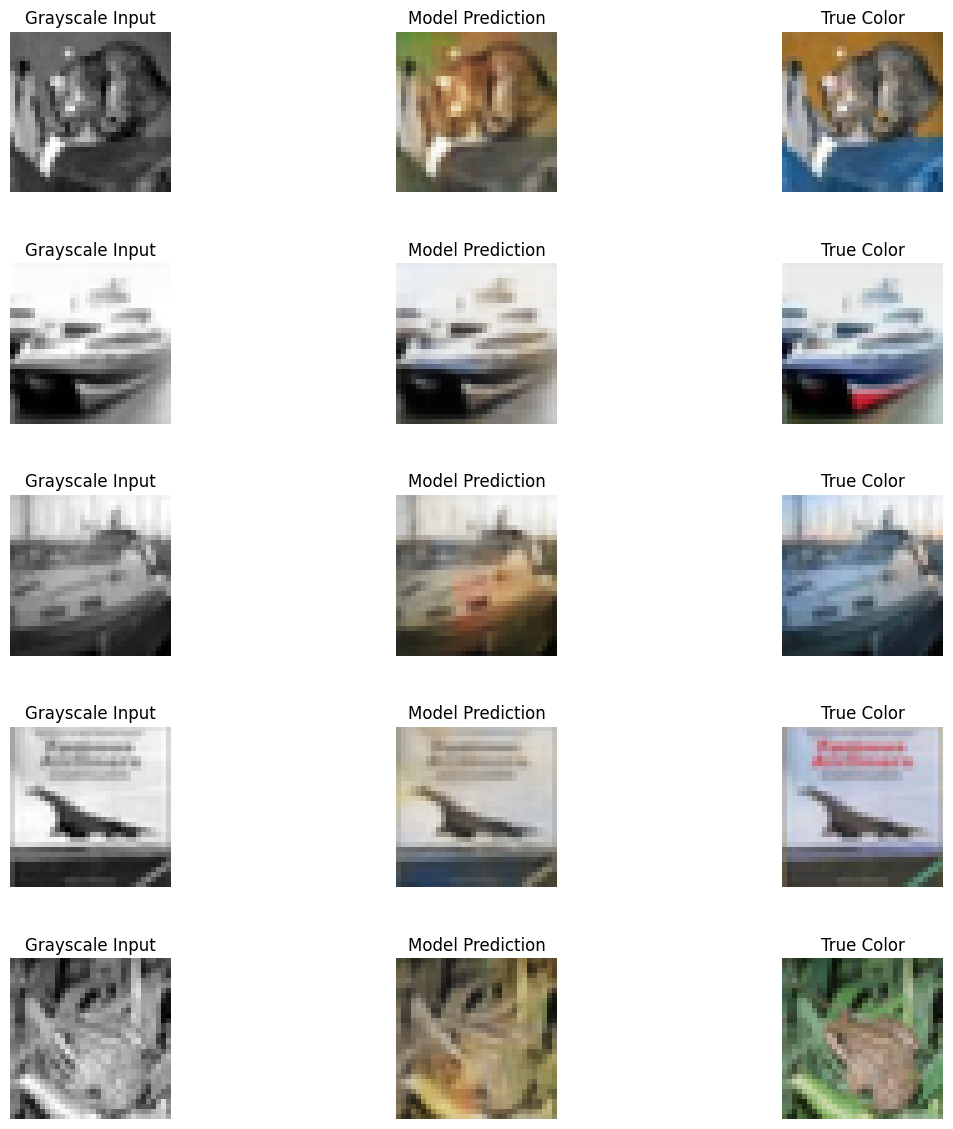

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select a few grayscale images from the test set
num_images_to_show = 5
test_images_grayscale = x_test_grayscale[:num_images_to_show]

# Use the trained model to predict the color versions
predicted_images = model.predict(test_images_grayscale)

# Plot the original grayscale, predicted, and true images
fig, axes = plt.subplots(num_images_to_show, 3, figsize=(12, 12))
fig.tight_layout(pad=3.0)

for i in range(num_images_to_show):
    # Grayscale image
    axes[i, 0].imshow(np.squeeze(test_images_grayscale[i]), cmap='gray')
    axes[i, 0].set_title('Grayscale Input')
    axes[i, 0].axis('off')

    # Predicted color image
    axes[i, 1].imshow(predicted_images[i])
    axes[i, 1].set_title('Model Prediction')
    axes[i, 1].axis('off')

    # True color image
    axes[i, 2].imshow(x_test[i])
    axes[i, 2].set_title('True Color')
    axes[i, 2].axis('off')

plt.show()